# Build Compound Event Catalog - Inland

Build the copula-joint design catalog from reviewed USGS streamflow records and direct AORC SST rainfall members. 

1. Source inventory: show driver libraries and marginal evidence
2. Extract POT events
3. Audit co-occurrence
4. Fit the copula
5. Sample AND-labeled design events
6. Produce Resilience-Design catalogue of 500 events

In [1]:
# imports, workspace path, and catalog runtime.
import sys
from pathlib import Path

location_root = Path("..").resolve()
repo_root = location_root.parents[1]
src_root = repo_root / "src"
sys.path.insert(0, str(src_root))
import geopandas as gpd
import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from IPython.display import display

from pyextremes import get_extremes
import pyvinecopulib as pvc
import yaml

# distribution, severity, and scaling plots.
from design_events import plotting as P
# paths and severity bands.
from design_events.build_events.workflow import (
    assign_severity_bands,
    load_runtime,
    materialize_inland_catalog_outputs,
)

pd.set_option("display.max_columns", 80)
plt.style.use("seaborn-v0_8-whitegrid")

runtime = load_runtime(location_root)
config = runtime.config
paths = runtime.runtime_paths
location_name = runtime.location_name


## Design Event Catalogue Parameters

 **importance-sampling and resource-allocation design** — Every selected row keeps its `probability_weight`, so enriching this set toward tail-heavy events does not bias the annualised estimate (Average Annual Outcome / EAD) — the weights correct the integral. This allows for oversampling the interesting events without distorting the risk number.

Design event split is user-driven. For this case, a tail-heavy 5/20/20/25/30 split is selected for 500 events.


In [2]:
# design-event simulation budget and severity mix.
resilience_stress_training = {
    "target_event_count": 500,
    "severity_band_fractions": {
        "mild": 0.05,
        "common": 0.20,
        "significant": 0.20,
        "rare": 0.25,
        "extreme": 0.30,
    },
    "benchmark_return_period_years": [10, 50, 100, 500],
}
config["resilience_stress_training"] = resilience_stress_training
config.setdefault("events", {})["target_event_count"] = resilience_stress_training["target_event_count"]

## Stage 1 - Source inventory and pairing policy

Configure member paths, pairing rules, and source status before fitting any frequency or dependence model.

### Forcing members

Rainfall and soil moisture are forcing-member libraries. Streamflow is retained as the Wflow-response validation anchor.

In [3]:
forcing_member_paths = dict(config["event_catalog"].get("forcing_members", {}))
config.setdefault("event_catalog", {})["forcing_members"] = forcing_member_paths

streamflow_csv = paths["usgs_streamgages_root"] / "streamflow_records.csv"
rainfall_csv = paths["aorc_sst_rainfall_members_csv"]
soil_moisture_csv = paths["nwm_soil_moisture_csv"]
output_catalog_csv = paths["catalog_root"] / "inland_design_event_catalog.csv"

display(pd.Series({
    "rainfall_members": forcing_member_paths.get("rainfall"),
    "streamflow_members": forcing_member_paths.get("streamflow"),
    "soil_moisture_members": forcing_member_paths.get("soil_moisture"),
    "output_catalog_csv": str(output_catalog_csv),
}, name="forcing_member_paths"))

rainfall_members                data/sources/aorc_sst/rainfall_members.csv
streamflow_members       data/sources/usgs_streamgages/streamflow_membe...
soil_moisture_members                   data/sources/nwm/soil_moisture.csv
output_catalog_csv       /home/grahamhults/projects/Flood-RM/locations/...
Name: forcing_member_paths, dtype: str

### Pairing policy

Rainfall prefers same-storm analogs, then falls back to seasonal-window permutation. Soil moisture is selected as antecedent state 24 hours before the paired rainfall/reference event.

In [4]:
pairing_policy = config["event_catalog"].get("pairing", {})
pairing = pairing_policy
rainfall_pairing = pairing_policy.get("rainfall", {})
streamflow_pairing = pairing_policy.get("streamflow", {})
soil_moisture_pairing = pairing_policy.get("soil_moisture", {})

display(pd.Series({
    "location": location_name,
    "rainfall_pairing": rainfall_pairing.get("strategy"),
    "rainfall_fallback_pairing": rainfall_pairing.get("fallback_strategy"),
    "rainfall_pairing_seed": rainfall_pairing.get("seed"),
    "rainfall_pairing_window_days": rainfall_pairing.get("window_days"),
    "streamflow_pairing": streamflow_pairing.get("strategy"),
    "soil_moisture_pairing": soil_moisture_pairing.get("strategy"),
    "soil_moisture_lead_time_hours": soil_moisture_pairing.get("lead_time_hours"),
}, name="source_pairing_parameters"))

location                                                     austin
rainfall_pairing                   inland_rainfall_pairing_priority
rainfall_fallback_pairing               seasonal_window_permutation
rainfall_pairing_seed                                             0
rainfall_pairing_window_days                                     45
streamflow_pairing                coherent_streamgage_network_event
soil_moisture_pairing            inland_antecedent_moisture_pairing
soil_moisture_lead_time_hours                                    24
Name: source_pairing_parameters, dtype: object

### Source status

Check Direct AORC SST rainfall, NWM soil moisture, and USGS reviewed streamflow records before loading driver libraries.

In [5]:
dependence = config["event_catalog"]["dependence"]
cooccurrence = dependence.get("cooccurrence", {})

# POT quantile: upper-tail cutoff; 0.95 keeps large events while retaining enough peaks to fit.
pot_quantile = float(cooccurrence.get("threshold_quantile", 0.95))
# Decluster window: storm-separation window; 120 hours avoids double-counting one hydrograph.
decluster_window_hours = float(cooccurrence.get("decluster_window_hours", 120))
min_peak_distance = pd.Timedelta(hours=decluster_window_hours)

copula_seed = int(dependence.get("copula_seed", 0))
target_design_events = int(resilience_stress_training["target_event_count"])
benchmark_return_periods = resilience_stress_training["benchmark_return_period_years"]

# Rainfall is the inland design driver; discharge is the Wflow response. The
# streamflow POT at the Primary Reference Gage is a calibration/validation + single-K anchor.
primary_reference_gage = str(config["inland_coupling"]["amplification"]["primary_reference_gage"])

rainfall_members = pd.read_csv(rainfall_csv)
soil_moisture_members = pd.read_csv(soil_moisture_csv)
soil_moisture_members.attrs["source_file"] = str(soil_moisture_csv)
streamflow_records_all = pd.read_csv(streamflow_csv, parse_dates=["time"], dtype={"site_no": str})

rainfall_time_column = next(column for column in ["storm_start", "storm_date", "time"] if column in rainfall_members)
rainfall_value_column = next(
    column for column in ["mean_precip_mm", "max_precip_mm", "mean", "max"] if column in rainfall_members
)
soil_value_column = next(
    (column for column in ["SOILSAT_TOP", "SOIL_M", "soil_moisture"] if column in soil_moisture_members),
    None,
)

source_inventory = pd.DataFrame([
    {
        "driver": "rainfall",
        "source": "Direct AORC SST",
        "role": "inland design driver (rainfall marginal / POT)",
        "path": str(rainfall_csv),
        "status": "complete" if rainfall_csv.exists() else "missing",
        "member_rows": len(rainfall_members),
        "value_column": rainfall_value_column,
    },
    {
        "driver": "antecedent soil moisture",
        "source": "NWM retrospective",
        "role": "antecedent conditioning state (not a copula axis)",
        "path": str(soil_moisture_csv),
        "status": "complete" if soil_moisture_csv.exists() else "missing",
        "member_rows": len(soil_moisture_members),
        "value_column": soil_value_column,
    },
    {
        "driver": "streamflow",
        "source": f"USGS Primary Reference Gage {primary_reference_gage}",
        "role": "Wflow-response calibration/validation + single-K anchor (NOT a design driver)",
        "path": str(streamflow_csv),
        "status": "complete" if streamflow_csv.exists() else "missing",
        "member_rows": len(streamflow_records_all),
        "value_column": "discharge_cfs",
    },
])

display(source_inventory)
display(pd.Series({
    "location": location_name,
    "design_driver": "rainfall + antecedent moisture",
    "primary_reference_gage": primary_reference_gage,
    "pot_quantile": pot_quantile,
    "decluster_window_hours": decluster_window_hours,
    "copula_seed": copula_seed,
    "target_design_events": target_design_events,
    "benchmark_return_periods": benchmark_return_periods,
}, name="event_catalog_parameters"))

,driver,source,role,path,status,member_rows,value_column
0,rainfall,Direct AORC SST,inland design driver (rainfall marginal / POT),/home/grahamhults/projects/Flood-RM/locations/...,complete,490,mean_precip_mm
1,antecedent soil moisture,NWM retrospective,antecedent conditioning state (not a copula axis),/home/grahamhults/projects/Flood-RM/locations/...,complete,4619232,SOILSAT_TOP
2,streamflow,USGS Primary Reference Gage 08155400,Wflow-response calibration/validation + single...,/home/grahamhults/projects/Flood-RM/locations/...,complete,274988,discharge_cfs


location                                            austin
design_driver               rainfall + antecedent moisture
primary_reference_gage                            08155400
pot_quantile                                          0.95
decluster_window_hours                               120.0
copula_seed                                              2
target_design_events                                   500
benchmark_return_periods                [10, 50, 100, 500]
Name: event_catalog_parameters, dtype: object

### Rainfall member preview

Plot the SST rainfall member distribution used by the inland catalog.

,member_id,source,member_file,storm_start,storm_end,duration_hours,rank,annual_rank,mean_precip_mm,max_precip_mm,min_precip_mm,precip_units,potential_method,centroid_lon,centroid_lat,historical_centroid_lon,historical_centroid_lat,transposed_centroid_lon,transposed_centroid_lat,transposition_offset_lon,transposition_offset_lat,historical_footprint_center_lon,historical_footprint_center_lat,target_footprint_center_lon,target_footprint_center_lat,transposition_region_id
0,rainfall_austin_72h_rank0001,aorc_sst,/home/grahamhults/projects/Flood-RM/locations/...,2017-08-25T18:00:00,2017-08-28T18:00:00,72,1,1,443.767361,598.600009,225.700003,mm,moving_footprint_max_mean,-97.401304,30.032932,-97.475120,30.128415,-97.843006,30.426428,-0.367886,0.298013,-97.401304,30.032932,-97.76919,30.330945,austin-inland-review-required
1,rainfall_austin_72h_rank0002,aorc_sst,/home/grahamhults/projects/Flood-RM/locations/...,2002-06-30T00:00:00,2002-07-03T00:00:00,72,2,1,297.972440,382.300006,191.100003,mm,moving_footprint_max_mean,-98.201272,30.099596,-98.001274,30.208295,-97.569193,30.439644,0.432082,0.231349,-98.201272,30.099596,-97.76919,30.330945,austin-inland-review-required
2,rainfall_austin_72h_rank0003,aorc_sst,/home/grahamhults/projects/Flood-RM/locations/...,1998-10-17T06:00:00,1998-10-20T06:00:00,72,3,1,262.073170,343.300005,169.900003,mm,moving_footprint_max_mean,-97.901284,29.899604,-97.776758,30.196453,-97.644664,30.627794,0.132094,0.431341,-97.901284,29.899604,-97.76919,30.330945,austin-inland-review-required
3,rainfall_austin_72h_rank0004,aorc_sst,/home/grahamhults/projects/Flood-RM/locations/...,2010-09-06T18:00:00,2010-09-09T18:00:00,72,4,1,260.546654,391.100006,123.100002,mm,moving_footprint_max_mean,-97.767956,30.766236,-97.881374,30.333082,-97.882608,29.897790,-0.001234,-0.435291,-97.767956,30.766236,-97.76919,30.330945,austin-inland-review-required
4,rainfall_austin_72h_rank0005,aorc_sst,/home/grahamhults/projects/Flood-RM/locations/...,1991-12-19T00:00:00,1991-12-22T00:00:00,72,5,1,227.611531,269.400004,186.700003,mm,moving_footprint_max_mean,-98.034612,30.199592,-97.854041,30.317688,-97.588619,30.449040,0.265422,0.131353,-98.034612,30.199592,-97.76919,30.330945,austin-inland-review-required


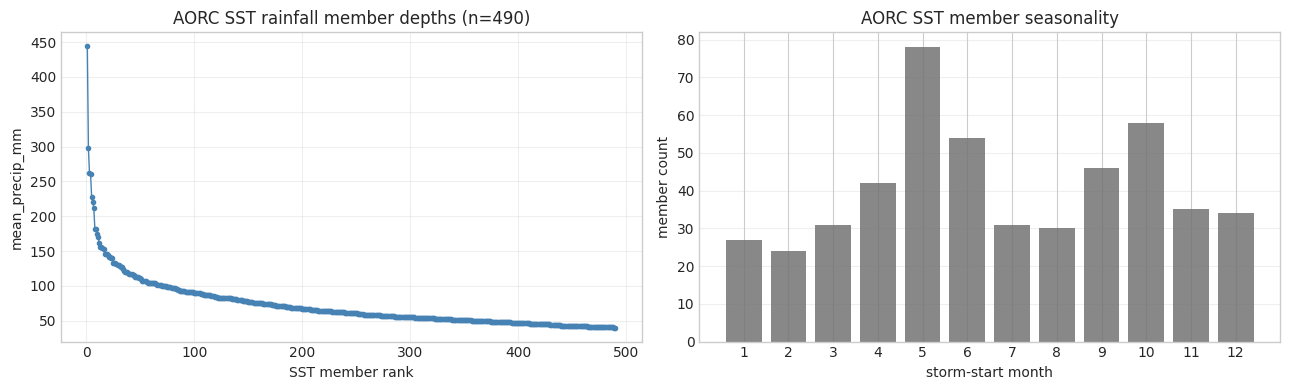

In [6]:
P.plot_rainfall(rainfall_members);
rainfall_members.head(5)

## Stage 2 - Streamflow validation anchor (Primary Reference Gage)

The streamflow POT at the Primary Reference Gage is the **Wflow-response calibration/validation + single-K anchor**, not the design frequency axis. The design driver is rainfall (Stage 3). For `austin_p5u`, the dominant inflow is the Highland Lakes-regulated Colorado mainstem (no on-reach gage); Barton Creek anchors the rainfall-runoff response, while the regulated mainstem warrants reservoir-aware handling.


### 2.1 Raw USGS Streamflow Records

Normalize the reviewed USGS site identifiers, isolate the Primary Reference Gage, and plot the record used for the streamflow validation anchor.


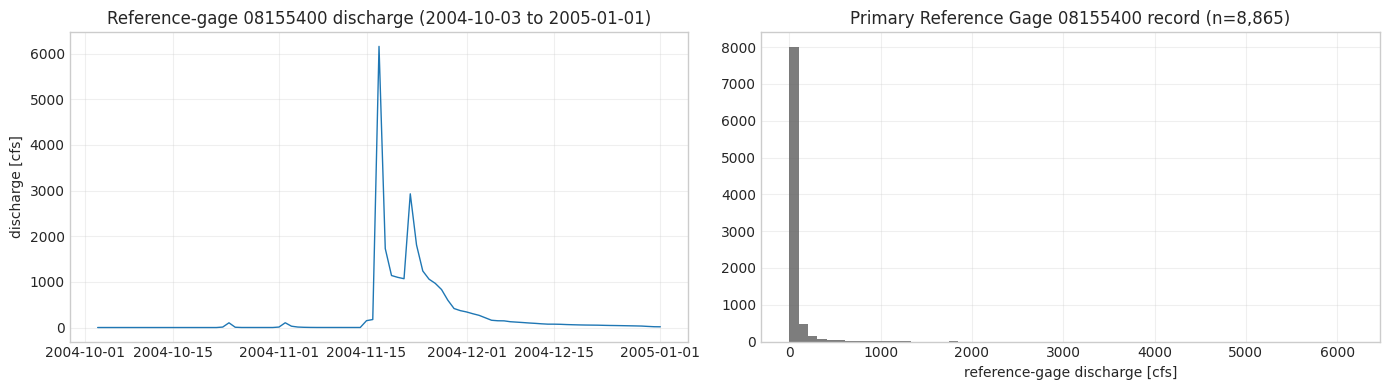

primary_reference_gage                                             08155400
reference_gage_rows                                                    8865
streamflow_start                                        1998-09-24 00:00:00
streamflow_end                                          2022-12-31 00:00:00
annual_mean_cfs                                                        41.3
median_baseflow_cfs                                                     1.7
note                      Wflow-readiness anchor; streamflow is validati...
Name: reference_gage_validation_anchor, dtype: object

In [7]:
# reference-gage discharge record for validation anchor.
# Normalize USGS site numbers because CSV round-trips and spreadsheet tools can
# turn leading-zero identifiers into numeric-looking strings such as "2094500.0".
def normalize_site_no(value):
    text = "" if pd.isna(value) else str(value).strip()
    if text.endswith(".0"):
        text = text[:-2]
    return text.zfill(8) if text.isdigit() and len(text) < 8 else text

streamflow_records_all["site_no"] = streamflow_records_all["site_no"].map(normalize_site_no)
primary_reference_gage_normalized = normalize_site_no(primary_reference_gage)

# The streamflow POT is the in-domain validation anchor at the Primary Reference
# Gage, not the retired cross-basin max-envelope and not the design driver.
reference_records = streamflow_records_all[
    streamflow_records_all["site_no"] == primary_reference_gage_normalized
].copy()
df_streamflow = reference_records.set_index("time")["discharge_cfs"].sort_index().to_frame()

# Plotting helpers expect the network-style long table: one row per site/time/value.
network_streamflow_records = df_streamflow.reset_index().assign(site_no=primary_reference_gage_normalized)
network_streamflow_records = network_streamflow_records[["site_no", "time", "discharge_cfs"]]

# Show the hydrograph neighborhood around the largest observed flow so the anchor
# record can be visually checked before extracting independent POT peaks.
peak_time = df_streamflow["discharge_cfs"].idxmax()
window_slice = (peak_time - pd.Timedelta(days=45), peak_time + pd.Timedelta(days=45))
window = df_streamflow.loc[window_slice[0]:window_slice[1], "discharge_cfs"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(window.index, window.values, lw=1.0)
axes[0].set_title(
    f"Reference-gage {primary_reference_gage_normalized} discharge "
    f"({window_slice[0]:%Y-%m-%d} to {window_slice[1]:%Y-%m-%d})"
)
axes[0].set_ylabel("discharge [cfs]")
axes[0].grid(True, alpha=0.3)
axes[1].hist(df_streamflow["discharge_cfs"].dropna().values, bins=60, color="0.4", alpha=0.85)
axes[1].set_title(f"Primary Reference Gage {primary_reference_gage_normalized} record (n={len(df_streamflow):,})")
axes[1].set_xlabel("reference-gage discharge [cfs]")
axes[1].grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

display(pd.Series({
    "primary_reference_gage": primary_reference_gage_normalized,
    "reference_gage_rows": len(reference_records),
    "streamflow_start": df_streamflow.index.min(),
    "streamflow_end": df_streamflow.index.max(),
    "annual_mean_cfs": round(float(df_streamflow["discharge_cfs"].mean()), 1),
    "median_baseflow_cfs": round(float(df_streamflow["discharge_cfs"].median()), 1),
    "note": "Wflow-readiness anchor; streamflow is validation/amplification evidence, not the design driver.",
}, name="reference_gage_validation_anchor"))


### 2.2 Peaks-over-threshold Extraction

Use the configured POT threshold and declustering window to extract independent streamflow events.

validation_anchor_gage            08155400
threshold_cfs                        177.0
independent_peak_events                 78
record_years                         24.27
configured_event_rate_per_year         5.0
Name: streamflow_validation_pot, dtype: object

,peak_flow_cfs,site_no,event_time,site_threshold_cfs,rank,sample_rp_years,sampling_region
time,,,,,,,
1998-10-17,2040.0,08155400,1998-10-17,177.0,10,2.426831,body
2000-06-10,644.0,08155400,2000-06-10,177.0,23,1.055144,body
2000-11-03,429.0,08155400,2000-11-03,177.0,37,0.655900,body
2000-12-27,492.0,08155400,2000-12-27,177.0,33,0.735403,body
2001-01-11,366.0,08155400,2001-01-11,177.0,43,0.564379,body


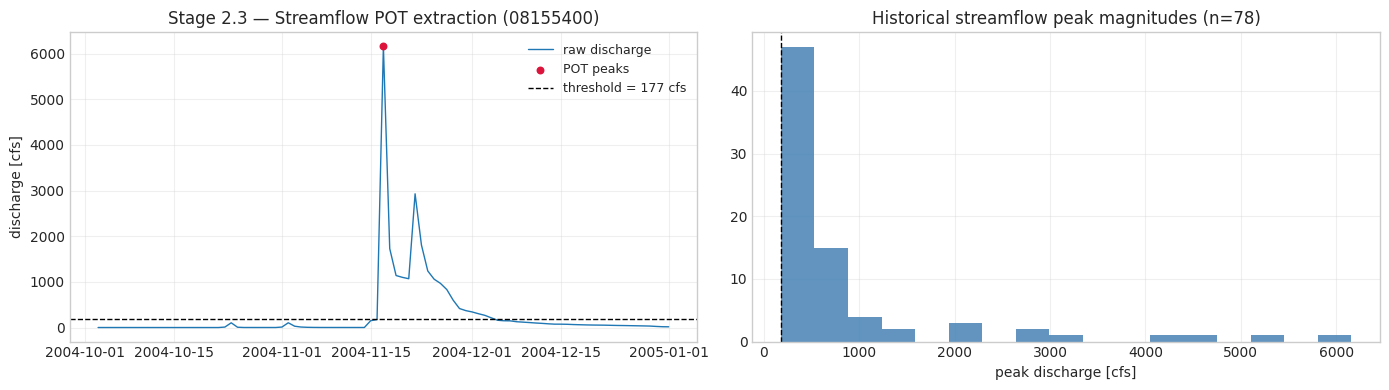

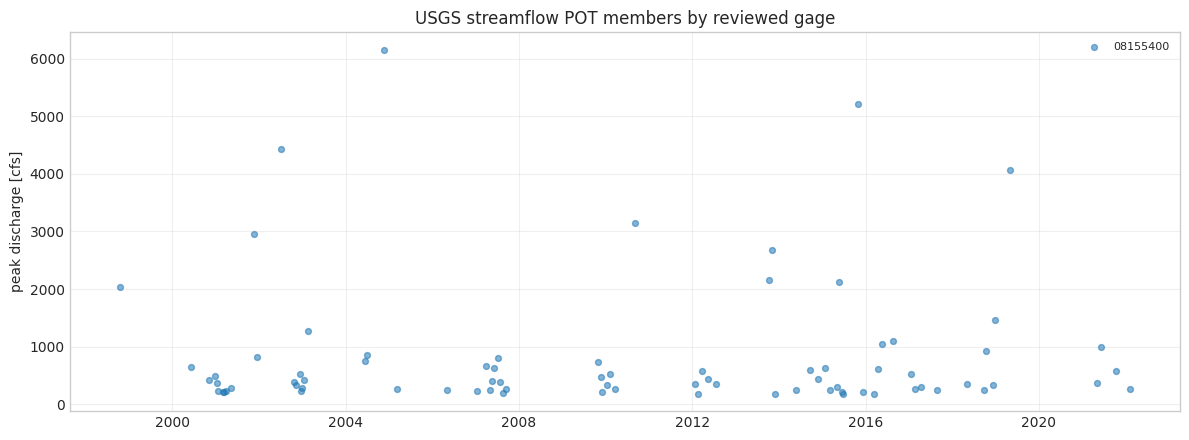

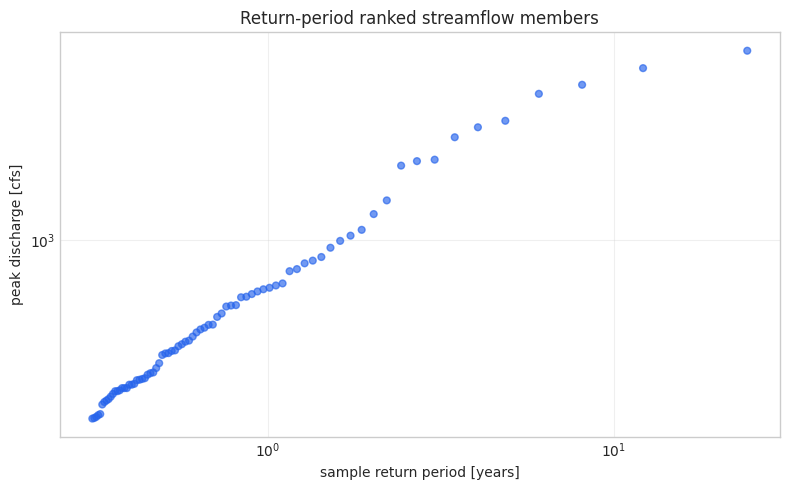

In [8]:
# independent streamflow peaks from the configured POT threshold.
ts_streamflow = df_streamflow["discharge_cfs"].dropna()
# POT threshold flow from the configured upper-tail quantile.
threshold_cfs = float(ts_streamflow.quantile(pot_quantile))
# pyextremes extracts independent Peaks Over Threshold; `r` is the declustering
# separation that prevents one multi-day hydrograph from contributing many peaks.
extremes = get_extremes(
    ts=ts_streamflow,
    method="POT",
    threshold=threshold_cfs,
    r=min_peak_distance,
)

# Convert the pyextremes Series into the project member-table shape used by plots
# and downstream validation: value, event time, threshold, rank, and empirical RP.
df_pot = extremes.to_frame(name="peak_flow_cfs").sort_index()
record_years = max((ts_streamflow.index.max() - ts_streamflow.index.min()) / pd.Timedelta(days=365.25), 1.0)
event_rate_per_year = float(dependence.get("event_rate_per_year") or (len(df_pot) / record_years))
streamflow_pot_members = df_pot.assign(
    site_no=primary_reference_gage_normalized,
    event_time=df_pot.index,
    site_threshold_cfs=threshold_cfs,
    rank=lambda frame: frame["peak_flow_cfs"].rank(method="first", ascending=False).astype(int),
)
streamflow_pot_members["sample_rp_years"] = record_years / streamflow_pot_members["rank"]
streamflow_pot_members["sampling_region"] = np.where(streamflow_pot_members["sample_rp_years"] >= 50, "tail", "body")

P.plot_streamflow_pot_extraction(
    network_streamflow_records,
    streamflow_pot_members,
    threshold_quantile=pot_quantile,
    site_no=primary_reference_gage_normalized,
);
P.plot_streamflow_pot_members(streamflow_pot_members);
P.plot_return_periods(streamflow_pot_members);

display(pd.Series({
    "validation_anchor_gage": primary_reference_gage_normalized,
    "threshold_cfs": threshold_cfs,
    "independent_peak_events": len(df_pot),
    "record_years": round(record_years, 2),
    "configured_event_rate_per_year": event_rate_per_year,
}, name="streamflow_validation_pot"))
streamflow_pot_members.head()


### 2.3 AIC Model Selection (Exp vs GPD)

empirical CDF on the left and log-survival tail behavior on the right. The fitted streamflow GPD is used for inverse transformation in the simple inland copula below.


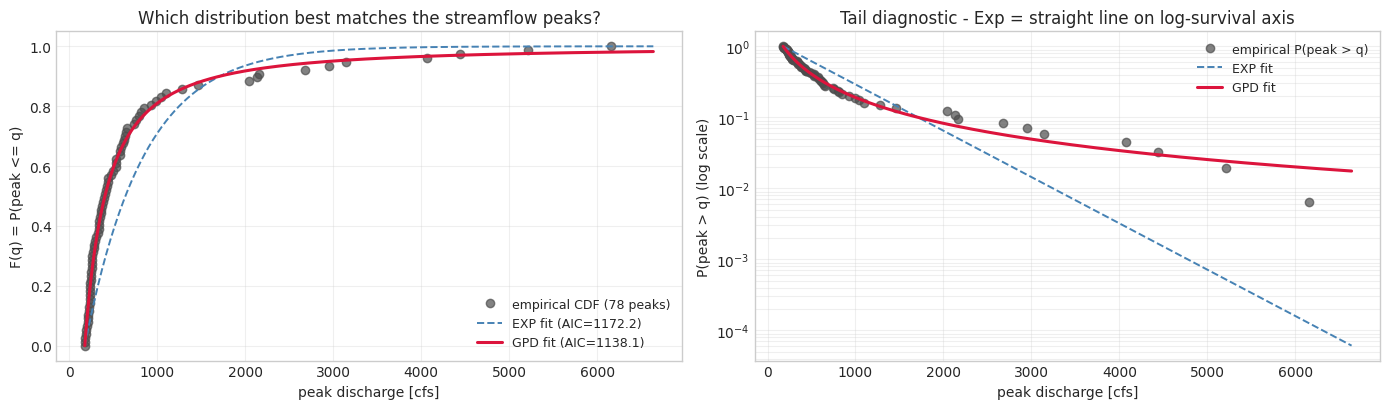

,distribution,aic,shape,scale
0,exp,1172.1651,NaN,665.8462
1,gpd,1138.1236,0.7406,251.9918


In [9]:
# exponential/GPD tail-fit comparison for streamflow peaks.
streamflow_exceedances = (df_pot["peak_flow_cfs"] - threshold_cfs).clip(lower=0).to_numpy(dtype=float)
streamflow_exceedances = streamflow_exceedances[np.isfinite(streamflow_exceedances)]

# Fit exceedances above the POT threshold. The exponential is the simple
# memoryless tail; the GPD allows tail shape and is the usual POT limit model.
exp_params = stats.expon.fit(streamflow_exceedances, floc=0)
gpd_params = stats.genpareto.fit(streamflow_exceedances, floc=0)

# AIC gives a compact likelihood-penalized comparison for the two tail choices.
def _aic(log_likelihood, n_params):
    return 2 * n_params - 2 * log_likelihood

exp_aic = _aic(float(np.sum(stats.expon.logpdf(streamflow_exceedances, *exp_params))), 1)
gpd_aic = _aic(float(np.sum(stats.genpareto.logpdf(streamflow_exceedances, *gpd_params))), 2)
shape_sf, loc_sf, scale_sf = gpd_params

sorted_excess = np.sort(streamflow_exceedances)
grid = np.linspace(0, max(sorted_excess.max() * 1.08, 1.0), 400)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
axes[0].plot(sorted_excess + threshold_cfs, np.linspace(0, 1, len(sorted_excess)), "o", color="0.3", alpha=0.7, label=f"empirical CDF ({len(sorted_excess):,} peaks)")
axes[0].plot(grid + threshold_cfs, stats.expon.cdf(grid, *exp_params), "--", color="steelblue", lw=1.4, label=f"EXP fit (AIC={exp_aic:.1f})")
axes[0].plot(grid + threshold_cfs, stats.genpareto.cdf(grid, *gpd_params), "-", color="crimson", lw=2.2, label=f"GPD fit (AIC={gpd_aic:.1f})")
axes[0].set_xlabel("peak discharge [cfs]")
axes[0].set_ylabel("F(q) = P(peak <= q)")
axes[0].set_title("Which distribution best matches the streamflow peaks?")
axes[0].legend(loc="lower right", fontsize=9)
axes[0].grid(True, alpha=0.3)

n = len(sorted_excess)
emp_surv = 1.0 - (np.arange(1, n + 1) - 0.5) / n
axes[1].semilogy(sorted_excess + threshold_cfs, emp_surv, "o", color="0.3", alpha=0.7, label="empirical P(peak > q)")
axes[1].semilogy(grid + threshold_cfs, stats.expon.sf(grid, *exp_params), "--", color="steelblue", lw=1.4, label="EXP fit")
axes[1].semilogy(grid + threshold_cfs, stats.genpareto.sf(grid, *gpd_params), "-", color="crimson", lw=2.2, label="GPD fit")
axes[1].set_xlabel("peak discharge [cfs]")
axes[1].set_ylabel("P(peak > q) (log scale)")
axes[1].set_title("Tail diagnostic - Exp = straight line on log-survival axis")
axes[1].legend(loc="upper right", fontsize=9)
axes[1].grid(True, alpha=0.3, which="both")
fig.tight_layout()
plt.show()

display(pd.DataFrame([
    {"distribution": "exp", "aic": exp_aic, "shape": np.nan, "scale": exp_params[-1]},
    {"distribution": "gpd", "aic": gpd_aic, "shape": shape_sf, "scale": scale_sf},
]).round(4))


### 2.4 Streamflow Return-period Curve

Trace the fitted streamflow tail into return-period space and overlay the same benchmark return periods used later for design-event coverage.


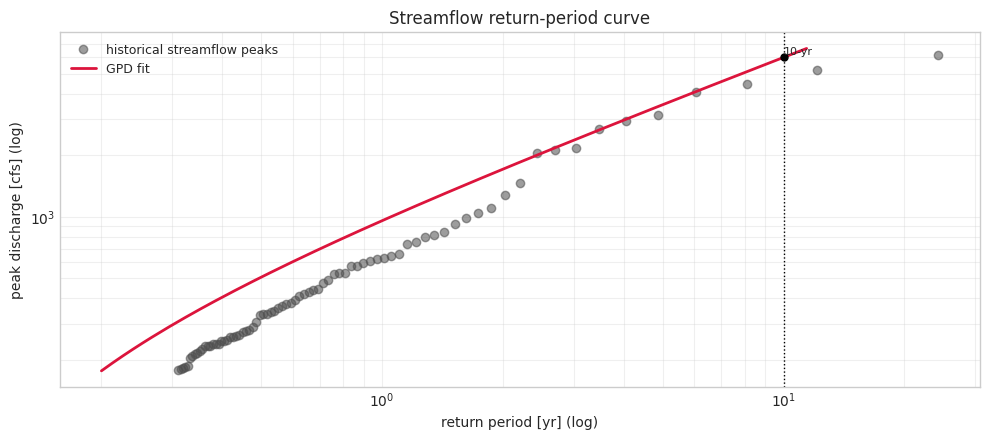

In [10]:
# streamflow return-period curve from the selected tail model.
q_grid = grid + threshold_cfs
# Convert the conditional GPD survival of threshold exceedances into annual
# exceedance rate by multiplying by the observed/configured POT event rate.
annual_exceedance = event_rate_per_year * stats.genpareto.sf(grid, c=shape_sf, loc=loc_sf, scale=scale_sf)
rp_grid = 1.0 / np.clip(annual_exceedance, 1e-12, None)
observed = streamflow_pot_members.sort_values("peak_flow_cfs", ascending=True).copy()
observed["observed_rp_years"] = record_years / np.arange(len(observed), 0, -1)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(observed["observed_rp_years"], observed["peak_flow_cfs"], "o", color="0.3", alpha=0.55, label="historical streamflow peaks")
ax.plot(rp_grid, q_grid, "-", color="crimson", lw=2, label="GPD fit")
for rp in benchmark_return_periods:
    if min(rp_grid) <= rp <= max(rp_grid):
        q_star = float(np.interp(np.log(rp), np.log(rp_grid), q_grid))
        ax.axvline(rp, ls=":", color="black", lw=1)
        ax.plot([rp], [q_star], "o", color="black", ms=5)
        ax.annotate(f"{int(rp)}-yr", xy=(rp, q_star), xytext=(rp, q_star * 1.03), fontsize=8)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("return period [yr] (log)")
ax.set_ylabel("peak discharge [cfs] (log)")
ax.set_title("Streamflow return-period curve")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3, which="both")
fig.tight_layout()
plt.show()


### 2.5 Stationarity Diagnostic on Selected Peaks

POT peaks through time with a Theil-Sen slope and a rank-correlation trend test.

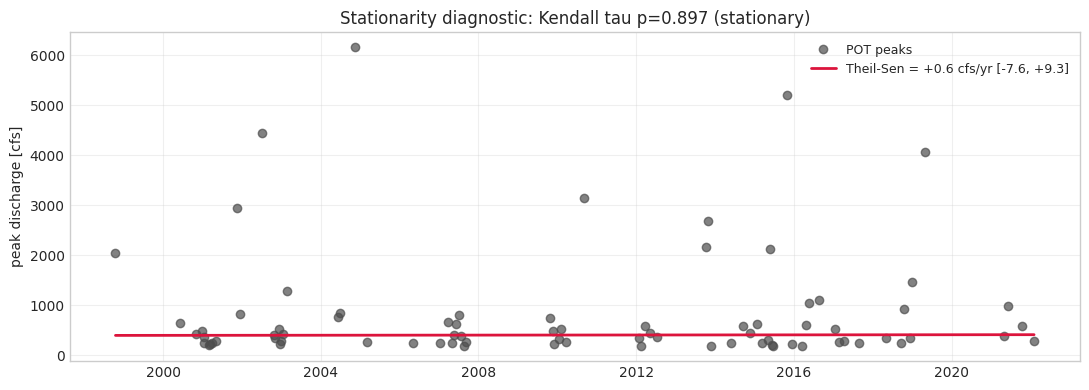

In [11]:
# stationarity check for selected streamflow peaks.
# A stationary POT sample supports using one historical event rate/tail model;
# strong trend evidence should trigger a reviewed nonstationary treatment.
peak_series = df_pot["peak_flow_cfs"].dropna().sort_index()
t_years = ((peak_series.index - peak_series.index.min()) / pd.Timedelta(days=365.25)).to_numpy(dtype=float)
y_peaks = peak_series.to_numpy(dtype=float)
ts_slope = stats.theilslopes(y_peaks, t_years, 0.95)
tau, trend_p = stats.kendalltau(t_years, y_peaks)
line_t = np.array([t_years.min(), t_years.max()])

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(peak_series.index, y_peaks, "o", color="0.3", alpha=0.7, label="POT peaks")
ax.plot(
    [peak_series.index.min(), peak_series.index.max()],
    ts_slope.intercept + ts_slope.slope * line_t,
    "-",
    color="crimson",
    lw=2,
    label=f"Theil-Sen = {ts_slope.slope:+.1f} cfs/yr [{ts_slope.low_slope:+.1f}, {ts_slope.high_slope:+.1f}]",
)
note = "stationary" if trend_p >= 0.05 else "trend detected"
ax.set_title(f"Stationarity diagnostic: Kendall tau p={trend_p:.3f} ({note})")
ax.set_ylabel("peak discharge [cfs]")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Stage 3 - Rainfall-driven design catalog

Rainfall is the single stochastic design driver (POT marginal); antecedent soil moisture conditions each event; **discharge is the Wflow response, not a copula dimension** (inland coupling policy). Built with the isolated `build_inland_catalog` (the shared coastal vine is untouched).

In [12]:
# rainfall catalog build and historical-tail sampling.
from design_events.build_events.probability import build_inland_catalog

inland_result = build_inland_catalog(
    config,
    paths,
    rainfall_members=rainfall_members,
    soil_moisture_members=(soil_moisture_members if not soil_moisture_members.empty else None),
    streamflow_records=streamflow_records_all,
    reference_gage=primary_reference_gage,
)
df_catalog = inland_result.catalog
# stress-set provenance columns the Stage 7 coverage plots expect
df_catalog["sampling_scheme"] = "band_stratified_importance_rainfall"
df_catalog["event_set"] = "resilience_stress_training"
df_catalog["selection_role"] = "resilience_stress_training"

display(pd.Series({
    "design_rows": len(df_catalog),
    "design_driver": df_catalog["event_drivers"].iloc[0],
    "forcing_pairing_policy": df_catalog["forcing_pairing_policy"].iloc[0],
    "rainfall_marginal": type(inland_result.rainfall_marginal).__name__,
    "rainfall_analogs": int(df_catalog["rainfall_member_id"].nunique()),
    "probability_weight_sum": round(float(df_catalog["probability_weight"].sum()), 4),
}, name="inland_design_catalog"))
display(inland_result.budget_report)
df_catalog.head(5)


design_rows                                                             500
design_driver                                                      rainfall
forcing_pairing_policy    rainfall_marginal_with_antecedent_moisture_wfl...
rainfall_marginal                                    HistoricalPeakMarginal
rainfall_analogs                                                         76
probability_weight_sum                                                  1.0
Name: inland_design_catalog, dtype: object

,severity_band,target,selected,met
0,mild,25,25,True
1,common,100,100,True
2,significant,100,100,True
3,rare,125,125,True
4,extreme,150,150,True


,event_id,rainfall_mm,sample_rp_years,severity_band,sampling_weight,probability_weight,catalog_role,scenario_name,rainfall_template_member_id,rainfall_template_value,rainfall_scale_factor,rainfall_design_method,rainfall_member_id,rainfall_member_file,rainfall_member_time,rainfall_realization_lag_hours,rainfall_source,soil_moisture_source,soil_moisture_member_file,soil_moisture_member_id,soil_moisture_member_time,soil_moisture_pairing_policy,soil_moisture_pairing_seed,soil_moisture_pairing_reference_time,soil_moisture_pairing_lag_hours,soil_moisture_metric,event_reference_time,forcing_pairing_policy,event_drivers,streamflow_design_role,study_location,wflow_event_dir,infiltration_treatment,streamflow_reference_gage,sampling_scheme,event_set,selection_role
0,design_0000,44.401661,0.231822,mild,0.055593,0.035989,inland_design,base,rainfall_austin_72h_rank0426,44.668403,0.994028,rainfall_marginal_scaled_aorc_sst_analog,rainfall_austin_72h_rank0426,/home/grahamhults/projects/Flood-RM/locations/...,2007-06-14T12:00:00,0.0,aorc_sst,nwm,/home/grahamhults/projects/Flood-RM/locations/...,soil_moisture_20070613T120000,2007-06-13T12:00:00,antecedent_to_forcing,0.0,2007-06-14T12:00:00,24.0,0.297778,2007-06-14 12:00:00,rainfall_marginal_with_antecedent_moisture_wfl...,rainfall,wflow_response,austin,data/wflow/events/design_0000,cn_with_recovery,08155400,band_stratified_importance_rainfall,resilience_stress_training,resilience_stress_training
1,design_0001,44.727424,0.234429,mild,0.055593,0.035989,inland_design,base,rainfall_austin_72h_rank0421,45.028994,0.993303,rainfall_marginal_scaled_aorc_sst_analog,rainfall_austin_72h_rank0421,/home/grahamhults/projects/Flood-RM/locations/...,1988-09-29T06:00:00,0.0,aorc_sst,nwm,/home/grahamhults/projects/Flood-RM/locations/...,soil_moisture_19880928T060000,1988-09-28T06:00:00,antecedent_to_forcing,0.0,1988-09-29T06:00:00,24.0,0.201667,1988-09-29 06:00:00,rainfall_marginal_with_antecedent_moisture_wfl...,rainfall,wflow_response,austin,data/wflow/events/design_0001,cn_with_recovery,08155400,band_stratified_importance_rainfall,resilience_stress_training,resilience_stress_training
2,design_0002,45.332710,0.239341,mild,0.055593,0.035989,inland_design,base,rainfall_austin_72h_rank0431,44.326517,1.022700,rainfall_marginal_scaled_aorc_sst_analog,rainfall_austin_72h_rank0431,/home/grahamhults/projects/Flood-RM/locations/...,1993-02-02T18:00:00,0.0,aorc_sst,nwm,/home/grahamhults/projects/Flood-RM/locations/...,soil_moisture_19930201T180000,1993-02-01T18:00:00,antecedent_to_forcing,0.0,1993-02-02T18:00:00,24.0,0.341667,1993-02-02 18:00:00,rainfall_marginal_with_antecedent_moisture_wfl...,rainfall,wflow_response,austin,data/wflow/events/design_0002,cn_with_recovery,08155400,band_stratified_importance_rainfall,resilience_stress_training,resilience_stress_training
3,design_0003,45.378305,0.239714,mild,0.055593,0.035989,inland_design,base,rainfall_austin_72h_rank0412,45.411179,0.999276,rainfall_marginal_scaled_aorc_sst_analog,rainfall_austin_72h_rank0412,/home/grahamhults/projects/Flood-RM/locations/...,2010-09-01T00:00:00,0.0,aorc_sst,nwm,/home/grahamhults/projects/Flood-RM/locations/...,soil_moisture_20100831T000000,2010-08-31T00:00:00,antecedent_to_forcing,0.0,2010-09-01T00:00:00,24.0,0.208333,2010-09-01 00:00:00,rainfall_marginal_with_antecedent_moisture_wfl...,rainfall,wflow_response,austin,data/wflow/events/design_0003,cn_with_recovery,08155400,band_stratified_importance_rainfall,resilience_stress_training,resilience_stress_training
4,design_0004,45.632313,0.241806,mild,0.055593,0.035989,inland_design,base,rainfall_austin_72h_rank0422,44.887616,1.016590,rainfall_marginal_scaled_aorc_sst_analog,rainfall_austin_72h_rank0422,/home/grahamhults/projects/Flood-RM/locations/...,1981-09-13T00:00:00,0.0,aorc_sst,nwm,/home/grahamhults/projects/Flood-RM/locations/...,soil_moisture_19810912T000000,1981-09-12T00:00:00,antecedent_to_forcing,0.0,1981-09-13T00:00:00,24.0,0.268333,1981-09-13 00:00:00,rainfall_marginal_with_antec

### 3.1 Rainfall design distribution and severity budget

The rainfall marginal return-period curve and the tail-enriched severity-band budget across the 500 design events.

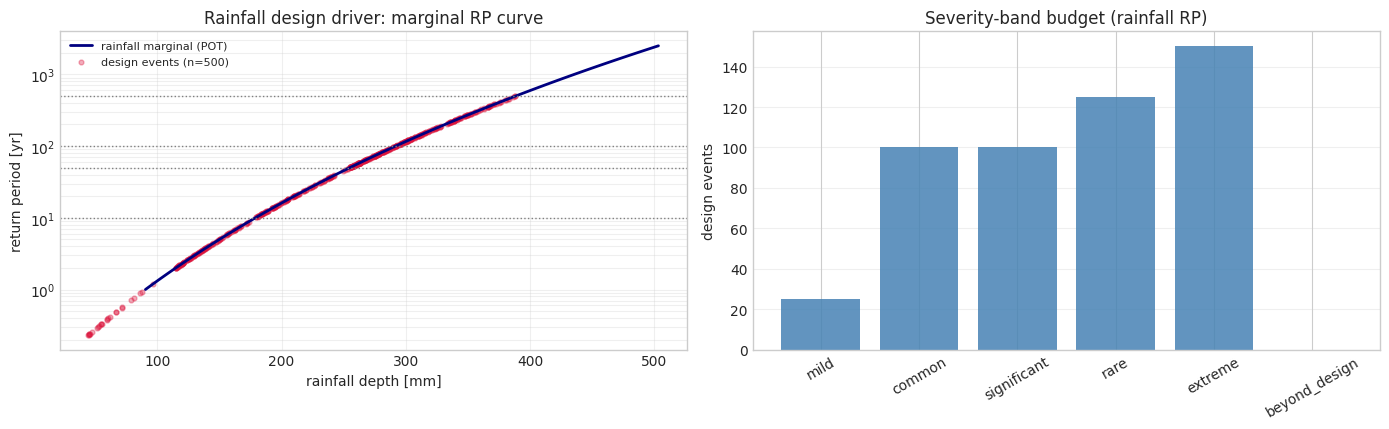

In [13]:
# rainfall marginal and selected event severity budget.
marg = inland_result.rainfall_marginal
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
rp_axis = np.logspace(0, np.log10(max(benchmark_return_periods) * 5), 120)
axes[0].plot([marg.magnitude(rp) for rp in rp_axis], rp_axis, "-", color="navy", lw=2, label="rainfall marginal (POT)")
axes[0].scatter(df_catalog["rainfall_mm"], df_catalog["sample_rp_years"], s=12, alpha=0.35, color="crimson", label=f"design events (n={len(df_catalog)})")
for rp in benchmark_return_periods:
    axes[0].axhline(rp, ls=":", color="0.5", lw=1)
axes[0].set_yscale("log")
axes[0].set_xlabel("rainfall depth [mm]")
axes[0].set_ylabel("return period [yr]")
axes[0].set_title("Rainfall design driver: marginal RP curve")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, which="both")

band_order = [b["severity_band"] for b in config["sampling"]["severity_bands"]]
counts = df_catalog["severity_band"].value_counts().reindex(band_order).fillna(0)
axes[1].bar(counts.index, counts.values, color="steelblue", alpha=0.85)
axes[1].set_title("Severity-band budget (rainfall RP)")
axes[1].set_ylabel("design events")
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(True, alpha=0.3, axis="y")
fig.tight_layout()
plt.show()


### 3.2 Streamflow validation anchor (response target)

The reference-gage POT frequency curve the rainfall-driven, Wflow-generated discharge ensemble must reproduce after the single-K Same-Frequency Amplification. Shown so the response-based frequency target is explicit — it is not a design driver.

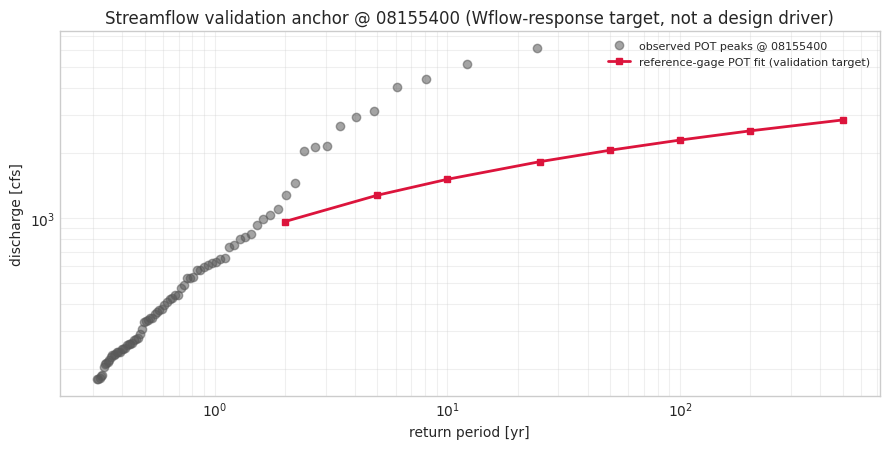

,streamflow_pot_cfs
2,965.0
5,1279.0
10,1516.0
25,1829.0
50,2067.0
100,2304.0
200,2541.0
500,2855.0


In [14]:
# streamflow response target for Wflow calibration/readiness.
ref_pot = inland_result.streamflow_reference_pot
fig, ax = plt.subplots(figsize=(9, 4.6))
obs = streamflow_pot_members.sort_values("peak_flow_cfs")
obs_rp = record_years / np.arange(len(obs), 0, -1)
ax.plot(obs_rp, obs["peak_flow_cfs"], "o", color="0.35", alpha=0.55, label=f"observed POT peaks @ {primary_reference_gage}")
if ref_pot is not None:
    ax.plot(ref_pot.index, ref_pot.values, "-s", color="crimson", lw=2, ms=4, label="reference-gage POT fit (validation target)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("return period [yr]")
ax.set_ylabel("discharge [cfs]")
ax.set_title(f"Streamflow validation anchor @ {primary_reference_gage} (Wflow-response target, not a design driver)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, which="both")
fig.tight_layout()
plt.show()

if ref_pot is not None:
    display(ref_pot.round(0).to_frame("streamflow_pot_cfs"))


### 3.3 Antecedent moisture conditioning

Antecedent soil-moisture state is the pre-storm wetness each design event carries into Wflow, sampled outside the copula. Seasonal coverage across the design set.

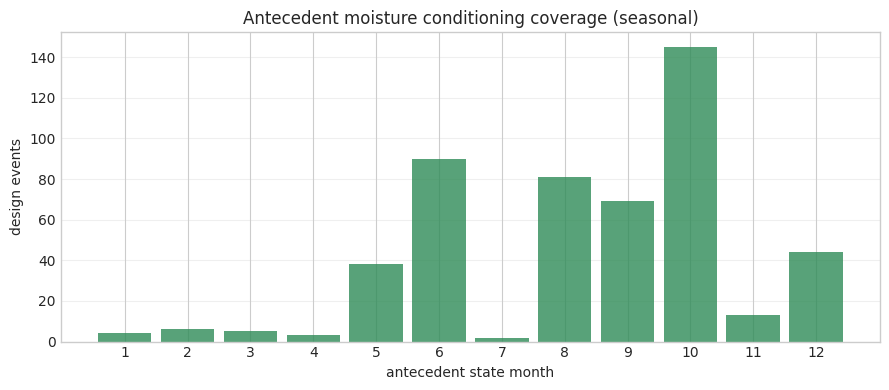

events_with_amc          500.0
amc_coverage_fraction      1.0
Name: antecedent_moisture, dtype: float64

In [15]:
# antecedent soil-moisture coverage for design events.
amc_col = next((c for c in ["soil_moisture_member_id", "soil_moisture_member_time"] if c in df_catalog.columns), None)
if amc_col and df_catalog[amc_col].notna().any():
    fig, ax = plt.subplots(figsize=(9, 4))
    amc_months = pd.to_datetime(df_catalog.get("soil_moisture_member_time"), errors="coerce").dt.month.dropna()
    if not amc_months.empty:
        ax.hist(amc_months, bins=range(1, 14), color="seagreen", alpha=0.8, align="left", rwidth=0.85)
        ax.set_xlabel("antecedent state month")
        ax.set_ylabel("design events")
        ax.set_xticks(range(1, 13))
    ax.set_title("Antecedent moisture conditioning coverage (seasonal)")
    ax.grid(True, alpha=0.3, axis="y")
    fig.tight_layout()
    plt.show()
    display(pd.Series({
        "events_with_amc": int(df_catalog[amc_col].notna().sum()),
        "amc_coverage_fraction": round(float(df_catalog[amc_col].notna().mean()), 3),
    }, name="antecedent_moisture"))
else:
    print("No antecedent soil-moisture members attached (NWM soil_moisture.csv absent); AMC conditioning skipped.")


### 3.4 Design catalog summary

Severity coverage, return-period ranges, and rainfall depths across the rainfall-driven design catalog.

,events,rp_min,rp_max,rainfall_min_mm,rainfall_max_mm,prob_mass
severity_band,,,,,,
mild,25.0,0.23,1.20,44.4,96.7,0.8997
common,100.0,2.01,8.87,115.0,173.8,0.0806
significant,100.0,10.10,48.50,179.4,253.4,0.0162
rare,125.0,50.30,97.83,255.2,290.6,0.0018
extreme,150.0,100.39,496.70,292.0,388.2,0.0016


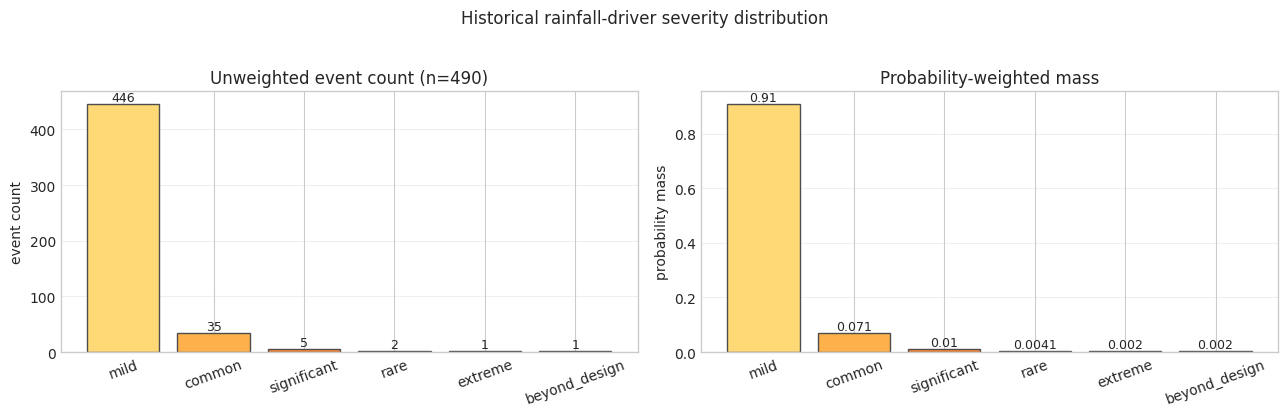

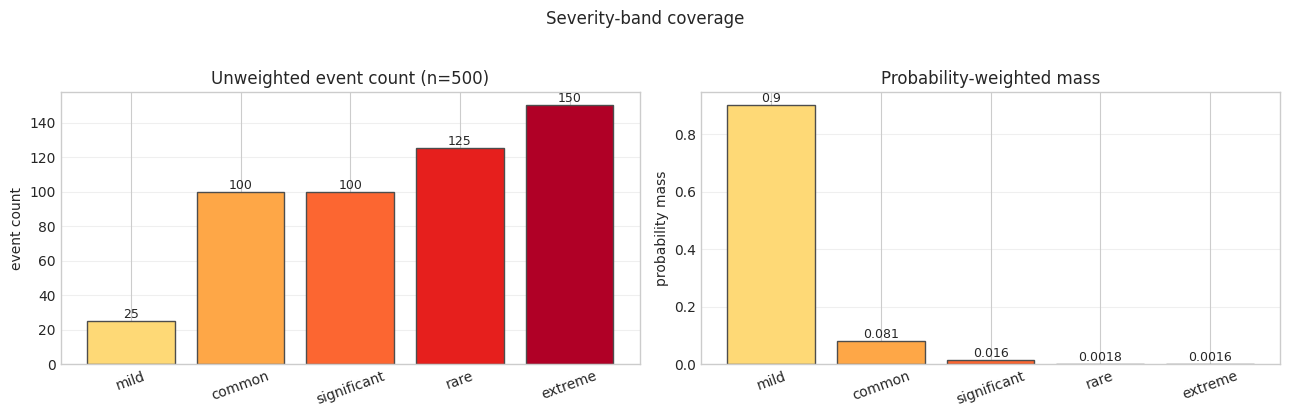

In [16]:
# historical rainfall-driver distribution, then selected design-catalog coverage.
historical_rainfall_catalog = rainfall_members.copy()
historical_rainfall_catalog["rainfall_mm"] = pd.to_numeric(
    historical_rainfall_catalog[rainfall_value_column], errors="coerce"
)
historical_rainfall_catalog["sample_rp_years"] = inland_result.rainfall_marginal.return_period(
    historical_rainfall_catalog["rainfall_mm"].to_numpy(dtype=float)
)
historical_rainfall_catalog["severity_band"] = assign_severity_bands(
    historical_rainfall_catalog["sample_rp_years"], config["sampling"]["severity_bands"]
)
historical_rainfall_catalog["probability_weight"] = 1.0 / max(len(historical_rainfall_catalog), 1)

fig = P.plot_severity_bands(historical_rainfall_catalog.dropna(subset=["rainfall_mm", "sample_rp_years"]))
fig.suptitle("Historical rainfall-driver severity distribution", y=1.03)
P.plot_severity_bands(df_catalog);

summary = df_catalog.groupby("severity_band").agg(
    events=("event_id", "size"),
    rp_min=("sample_rp_years", "min"),
    rp_max=("sample_rp_years", "max"),
    rainfall_min_mm=("rainfall_mm", "min"),
    rainfall_max_mm=("rainfall_mm", "max"),
    prob_mass=("probability_weight", "sum"),
).reindex([b["severity_band"] for b in config["sampling"]["severity_bands"]]).dropna(how="all")
display(summary.round({"rp_min": 2, "rp_max": 2, "rainfall_min_mm": 1, "rainfall_max_mm": 1, "prob_mass": 4}))


## Stage 7 - Wflow readiness replay set

Severity-band coverage, benchmark return-period coverage, and row previews.

### 7.1 Selected Design Catalog Severity Ranges

These severity labels are keyed to pre-SFINCS AND return period from the fitted copula, not to flood-response AEP. The configured return-period ranges are shown first so the labels are concrete before plotting the design catalog.


In [17]:
# severity-band ranges for selected design catalog.
severity_ranges = pd.DataFrame(config["sampling"]["severity_bands"])
severity_ranges["and_joint_return_period_range"] = severity_ranges.apply(
    lambda row: (
        f">= {row['rp_min_years']:g} yr" if pd.isna(row["rp_max_years"])
        else f"{row['rp_min_years']:g} to <{row['rp_max_years']:g} yr"
    ),
    axis=1,
)
severity_ranges["annual_chance_range"] = severity_ranges.apply(
    lambda row: (
        f"<= {100 / row['rp_min_years']:g}%" if pd.isna(row["rp_max_years"]) and row["rp_min_years"] > 0
        else (
            f"> {100 / row['rp_max_years']:g}% to <= {100 / row['rp_min_years']:g}%"
            if row["rp_min_years"] > 0 else f"> {100 / row['rp_max_years']:g}%"
        )
    ),
    axis=1,
)
display(severity_ranges[["severity_band", "and_joint_return_period_range", "annual_chance_range"]])


,severity_band,and_joint_return_period_range,annual_chance_range
0,mild,0 to <2 yr,> 50%
1,common,2 to <10 yr,> 10% to <= 50%
2,significant,10 to <50 yr,> 2% to <= 10%
3,rare,50 to <100 yr,> 1% to <= 2%
4,extreme,100 to <500 yr,> 0.2% to <= 1%
5,beyond_design,>= 500 yr,<= 0.2%


### 7.2 Resilience Stress/Training Coverage

The final resilience set is the configured 500-event band-stratified stress/training catalog. Keep the compact severity-band review and table preview; the candidate-pool budget plot is omitted because it repeats the selected-row allocation.


In [18]:
# high-fidelity simulation budget coverage by severity.
stress_training_catalog = df_catalog.copy()
stress_summary = pd.Series({
    "stress_training_rows": len(stress_training_catalog),
    "sampling_scheme": stress_training_catalog["sampling_scheme"].iloc[0],
    "mild_rows": int((stress_training_catalog["severity_band"] == "mild").sum()),
    "mild_fraction": float((stress_training_catalog["severity_band"] == "mild").mean()),
    "probability_weight_sum": float(stress_training_catalog["probability_weight"].sum()),
    "benchmark_return_periods": benchmark_return_periods,
}, name="resilience_stress_training")
display(stress_summary)

stress_preview = stress_training_catalog.sort_values("sample_rp_years", ascending=False)
display(stress_preview[[
    "event_id", "sample_rp_years", "severity_band", "sampling_weight", "probability_weight",
    "rainfall_mm", "rainfall_member_id",
]].head(16).round({"sample_rp_years": 2, "sampling_weight": 3, "probability_weight": 8, "rainfall_mm": 1}))


stress_training_rows                                        500
sampling_scheme             band_stratified_importance_rainfall
mild_rows                                                    25
mild_fraction                                              0.05
probability_weight_sum                                      1.0
benchmark_return_periods                     [10, 50, 100, 500]
Name: resilience_stress_training, dtype: object

,event_id,sample_rp_years,severity_band,sampling_weight,probability_weight,rainfall_mm,rainfall_member_id
499,design_0499,496.70,extreme,184.049,0.000011,388.2,rainfall_austin_72h_rank0001
498,design_0498,494.46,extreme,184.049,0.000011,387.9,rainfall_austin_72h_rank0001
497,design_0497,480.42,extreme,184.049,0.000011,386.0,rainfall_austin_72h_rank0003
496,design_0496,458.06,extreme,184.049,0.000011,382.9,rainfall_austin_72h_rank0001
495,design_0495,453.86,extreme,184.049,0.000011,382.3,rainfall_austin_72h_rank0001
494,design_0494,444.74,extreme,184.049,0.000011,381.0,rainfall_austin_72h_rank0002
493,design_0493,434.18,extreme,184.049,0.000011,379.5,rainfall_austin_72h_rank0002
492,design_0492,414.60,extreme,184.049,0.000011,376.5,rainfall_austin_72h_rank0001
491,design_0491,412.53,extreme,184.049,0.000011,376.2,rainfall_austin_72h_rank0005
490,design_0490,403.09,extreme,184.049,0.000011,374.7,rainfall_austin_72h_rank0001


## Stage 8 - Hand off to Wflow and SFINCS

Each design row is matched to the closest observed streamflow POT analog and closest rainfall member, then gets scale factors that downstream model builders can use to preserve observed temporal fields while scaling their magnitudes.


,event_id,catalog_role,sample_rp_years,severity_band,sampling_weight,probability_weight,rainfall_mm,rainfall_member_id,rainfall_scale_factor,soil_moisture_member_id,forcing_pairing_policy,event_drivers,streamflow_design_role
0,design_0000,inland_design,0.23,mild,0.056,0.035989,44.4,rainfall_austin_72h_rank0426,0.994,soil_moisture_20070613T120000,rainfall_marginal_with_antecedent_moisture_wfl...,rainfall,wflow_response
1,design_0001,inland_design,0.23,mild,0.056,0.035989,44.7,rainfall_austin_72h_rank0421,0.993,soil_moisture_19880928T060000,rainfall_marginal_with_antecedent_moisture_wfl...,rainfall,wflow_response
2,design_0002,inland_design,0.24,mild,0.056,0.035989,45.3,rainfall_austin_72h_rank0431,1.023,soil_moisture_19930201T180000,rainfall_marginal_with_antecedent_moisture_wfl...,rainfall,wflow_response
3,design_0003,inland_design,0.24,mild,0.056,0.035989,45.4,rainfall_austin_72h_rank0412,0.999,soil_moisture_20100831T000000,rainfall_marginal_with_antecedent_moisture_wfl...,rainfall,wflow_response
4,design_0004,inland_design,0.24,mild,0.056,0.035989,45.6,rainfall_austin_72h_rank0422,1.017,soil_moisture_19810912T000000,rainfall_marginal_with_antecedent_moisture_wfl...,rainfall,wflow_response
5,design_0005,inland_design,0.26,mild,0.056,0.035989,47.7,rainfall_austin_72h_rank0377,0.979,soil_moisture_19910201T120000,rainfall_marginal_with_antecedent_moisture_wfl...,rainfall,wflow_response
6,design_0006,inland_design,0.29,mild,0.056,0.035989,51.2,rainfall_austin_72h_rank0341,0.995,soil_moisture_19910410T180000,rainfall_marginal_with_antecedent_moisture_wfl...,rainfall,wflow_response
7,design_0007,inland_design,0.30,mild,0.056,0.035989,52.4,rainfall_austin_72h_rank0330,0.999,soil_moisture_20060526T120000,rainfall_marginal_with_antecedent_moisture_wfl...,rainfall,wflow_response


event_catalog_rows                                                               500
design_driver                      rainfall + antecedent moisture (discharge = Wf...
inland_design_event_catalog_csv    /home/grahamhults/projects/Flood-RM/locations/...
probability_catalog_csv            /home/grahamhults/projects/Flood-RM/locations/...
scenario_catalog_csv               /home/grahamhults/projects/Flood-RM/locations/...
scenario_catalog_rows                                                            507
wflow_scenario_replay_set_csv      /home/grahamhults/projects/Flood-RM/locations/...
rainfall_analog_count                                                             76
validation_anchor_gage                                                      08155400
Name: event_catalog_handoff, dtype: object

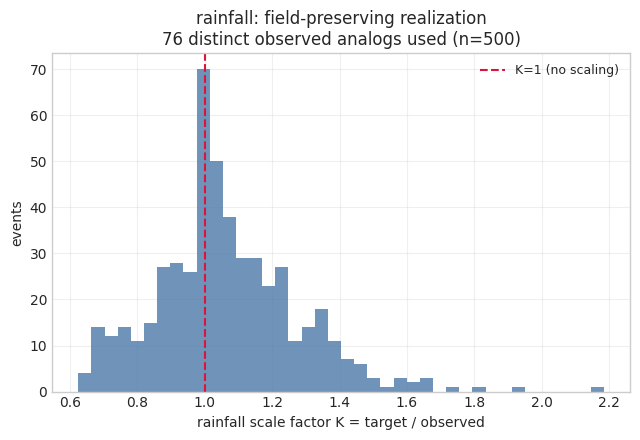

In [19]:
# Wflow/SFINCS handoff artifacts from the selected inland catalog.
# Discharge is generated downstream by Wflow; member files are normalized location-relative.
stress_training_catalog = df_catalog.copy()
catalog_outputs = materialize_inland_catalog_outputs(
    runtime=runtime,
    event_catalog=df_catalog,
    stress_training_catalog=stress_training_catalog,
    selected_catalog_csv=output_catalog_csv,
    summary_fields={"validation_anchor_gage": primary_reference_gage},
)
df_catalog = catalog_outputs["event_catalog"]
stress_training_catalog = catalog_outputs["stress_training_catalog"]
scenario_catalog = catalog_outputs["scenario_catalog"]

P.plot_scaling(df_catalog, "rainfall");
display(catalog_outputs["preview"])
display(catalog_outputs["summary"])
